# 13. Final synthetic synthesis

This notebook synthesises the exploration and validation of Linus' Simple Event Volatility Model. It is a read-only consolidation: it loads saved checkpoints and stored notebook outputs, and does not rerun a source experiment or introduce a new model.

Evidence is separated deliberately: **Level 1** is structural and workflow validation (Notebooks 00–06); **Level 2** is repeated-seed or broader robustness evidence (08–11); and **Level 3** is focused one-seed exploration (07 and 12). The latter is diagnostic evidence, not a general conclusion.

## Model and frozen timing

The synthetic model uses \(S_{t+1}=S_t(1+\sigma_t\epsilon_t)\), \(X_t=\sigma_t^n\), and

\[X_{t+1}=\omega_{t+1}^{n/2}\left[X_t+\alpha_t\Delta t+\nu_t\left(\rho_t\epsilon_t+\sqrt{1-\rho_t^2}\eta_t\right)\right].\]

The frozen timing is \(E_t\longrightarrow\omega_{t+1}\longrightarrow X_{t+1}\): lag (+1) is the exact structural lag and (+1,…,+13) is the direct response window. The synthetic environment permits post-fit comparison with a **Known-DGP reference**. GC, TDMI and TE remain predictive diagnostics, not interventionist causality; reverse GC or TE is a reverse predictive diagnostic, not physical volatility-to-event causation.

## Load saved evidence and establish provenance

Only machine-readable checkpoints and stored outputs are read below. Assertions make missing required checkpoints explicit, and the resulting provenance table distinguishes automated checkpoint extraction from manual stored-output reading.

In [1]:
from pathlib import Path
from datetime import datetime, timezone
import json

import matplotlib.pyplot as plt
import nbformat
import numpy as np
import pandas as pd
from IPython.display import Markdown, display

ROOT = Path.cwd()
OUTPUT_DIR = ROOT / 'notebook13_results'
OUTPUT_DIR.mkdir(exist_ok=True)

source_files = {
    'notebook08_numeric': ROOT / 'notebook08_results' / 'notebook08_numeric_summary.csv',
    'notebook09_numeric': ROOT / 'notebook09_results' / 'notebook09_calibration_numeric_summary.csv',
    'notebook10_schedule': ROOT / 'notebook10_results' / 'stage4_seed_case_analysis.csv',
    'notebook10_headlines': ROOT / 'notebook10_results' / 'stage5_headline_results.csv',
    'notebook11_config': ROOT / 'notebook11_results' / 'experiment_config.json',
    'notebook11_metrics': ROOT / 'notebook11_results' / 'run_metrics.csv',
    'notebook11_te_validation': ROOT / 'notebook11_results' / 'te_validation.csv',
    'notebook11_manifest': ROOT / 'notebook11_results' / 'manifest.json',
    'notebook12': ROOT / '12_log_state_event_decomposition.ipynb',
}
missing_required = [name for name, path in source_files.items() if not path.exists()]
assert not missing_required, f'Missing required source files: {missing_required}'

summary08 = pd.read_csv(source_files['notebook08_numeric'])
summary09 = pd.read_csv(source_files['notebook09_numeric'])
schedule_runs = pd.read_csv(source_files['notebook10_schedule'])
schedule_headlines = pd.read_csv(source_files['notebook10_headlines'])
run_metrics = pd.read_csv(source_files['notebook11_metrics'])
te_validation = pd.read_csv(source_files['notebook11_te_validation'])
config11 = json.loads(source_files['notebook11_config'].read_text(encoding='utf-8'))
manifest11 = json.loads(source_files['notebook11_manifest'].read_text(encoding='utf-8'))

nb12 = nbformat.read(source_files['notebook12'], as_version=4)
stored_output_text = '\n'.join(
    ''.join(output.get('data', {}).get('text/markdown', []))
    for cell in nb12.cells
    for output in cell.get('outputs', [])
    if output.get('output_type') in {'display_data', 'execute_result'}
)
assert 'mostly inferior' in stored_output_text
assert manifest11['failure_count'] == 0
assert te_validation['pass'].all()

source_experiments_rerun = False
print(f'Loaded Notebook 11 metrics: {len(run_metrics):,} rows')
print(f'Notebook 11 TE validation passed: {te_validation["pass"].all()}')
print(f'Source experiments rerun: {source_experiments_rerun}')

Loaded Notebook 11 metrics: 2,500 rows
Notebook 11 TE validation passed: True
Source experiments rerun: False


## Experiment map and evidence hierarchy

The registry treats the notebook sequence as one synthetic model-sheet exploration, rather than as thirteen independent research questions. It records the evidential boundary for every stage.

In [2]:
registry_rows = [
    ('00', 'Model specification and core simulator', 'Dense periodic n=1 foundation', 'simulation and timing', 'deterministic specification', 'model and timing checks', 'Level 1', 'synthetic and simple calendar'),
    ('01', 'Dense-periodic n=1 dependence exploration', 'Dense periodic n=1', 'GC and TDMI', 'one seed', 'lagged dependence curves', 'Level 1', 'periodic aliasing'),
    ('02', 'Predictive direction and structure diagnostics', 'Dense periodic n=1', 'GC and conditional structure', 'one seed', 'directional diagnostic tables', 'Level 1', 'predictive, not interventionist'),
    ('03', 'Event-weight and profile estimation', 'Dense periodic n=1', 'parametric and non-parametric profiles', 'one seed', 'profile recovery', 'Level 1', 'single simulated path'),
    ('04', 'Event-aware volatility forecasting', 'Dense periodic n=1', 'unaware and event-aware forecasts', 'one seed', 'forecast paths', 'Level 1', 'single simulated path'),
    ('05', 'Forecast evaluation and calibration', 'Dense periodic n=1', 'MAE, RMSE and intervals', 'one seed', 'accuracy and interval metrics', 'Level 1', 'calibration is sample-specific'),
    ('06', 'Reusable workflow helpers', 'frozen reusable workflow', 'simulation through evaluation', 'helper validation suite', 'leakage-safe pipeline', 'Level 1', 'synthetic scope'),
    ('07', 'Nonlinear functional robustness', 'state-dependent background function', 'workflow diagnostic', 'one seed', 'focused robustness output', 'Level 3', 'not repeated-seed evidence'),
    ('08', 'Scalar-parameter and replication robustness', 'n=1 parameter cases', 'profiles, GC, TDMI, forecasts', '50 seeds per case', 'repeated summaries and contrasts', 'Level 2', 'studied parameter grid'),
    ('09', 'Full n=2 analysis', 'locally scale-matched n=2', 'profiles, diagnostics, forecasts', '50 seeds', 'n=2 repeated summaries', 'Level 2', 'scale-aware comparison required'),
    ('10', 'Event-frequency and schedule robustness', 'dense, sparse periodic, sparse irregular', 'GC, TDMI, profiles, forecasts', '50 paired seeds', 'schedule contrasts', 'Level 2', 'three studied schedules'),
    ('11', 'Dependence and causality comparison', 'four non-null cases plus no effect', 'correlation, GC, TDMI, validated TE', '50 seeds', 'detection and lag-recovery rates', 'Level 2', 'predictive diagnostics'),
    ('12', 'Log-state additive decomposition', 'dense periodic n=1', 'matched-feature log target', 'one seed', 'decomposition comparison', 'Level 3', 'frozen linear raw predictor basis'),
]
experiment_registry = pd.DataFrame(
    registry_rows,
    columns=[
        'notebook', 'purpose', 'main model case', 'methods used',
        'number of seeds or replications', 'primary output',
        'evidence level', 'main limitation',
    ],
)
experiment_registry.to_csv(OUTPUT_DIR / 'experiment_registry.csv', index=False)
display(experiment_registry)

,notebook,purpose,main model case,methods used,number of seeds or replications,primary output,evidence level,main limitation
0,00,Model specification and core simulator,Dense periodic n=1 foundation,simulation and timing,deterministic specification,model and timing checks,Level 1,synthetic and simple calendar
1,01,Dense-periodic n=1 dependence exploration,Dense periodic n=1,GC and TDMI,one seed,lagged dependence curves,Level 1,periodic aliasing
2,02,Predictive direction and structure diagnostics,Dense periodic n=1,GC and conditional structure,one seed,directional diagnostic tables,Level 1,"predictive, not interventionist"
3,03,Event-weight and profile estimation,Dense periodic n=1,parametric and non-parametric profiles,one seed,profile recovery,Level 1,single simulated path
4,04,Event-aware volatility forecasting,Dense periodic n=1,unaware and event-aware forecasts,one seed,forecast paths,Level 1,single simulated path
5,05,Forecast evaluation and calibration,Dense periodic n=1,"MAE, RMSE and intervals",one seed,accuracy and interval metrics,Level 1,calibration is sample-specific
6,06,Reusable workflow helpers,frozen reusable workflow,simulation through evaluation,helper validation suite,leakage-safe pipeline,Level 1,synthetic scope
7,07,Nonlinear functional robustness,state-dependent background function,workflow diagnostic,one seed,focused robustness output,Level 3,not repeated-seed evidence
8,08,Scalar-parameter and replication robustness,n=1 parameter cases,"profiles, GC, TDMI, forecasts",50 seeds per case,repeated summaries and contrasts,Level 2,studied parameter grid
9,09,Full n=2 analysis,locally scale-matched n=2,"profiles, diagnostics, forecasts",50 seeds,n=2 repeated summaries,Level 2,scale-aware comparison required


## Dependence, direction and lag recovery

Notebook 11 is the primary quantitative source. To compare methods on one common representation, the table uses change-series results. The four non-null cases supply signal performance; held-out no-effect seeds supply false-positive rates. For GC p=1, rejection is exact-(+1) Granger-predictive evidence because lag (+1) was prespecified. For GC p=13, the direct-history test is joint and unique exact-lag recovery is not applicable.

,method,forward dependence detection,reverse detection,forward-only rate,bidirectional rate,exact (+1) recovery,exact (+1) conditional on forward detection,exact-lag interpretation,direct-window recovery,held-out forward false-positive rate,held-out reverse false-positive rate,source notebook,source file,evidence type
0,Lagged correlation,0.950,0.765,0.195,0.755,0.520,0.536842,Peak-based exact (+1) recovery,0.540,0.08,0.12,11,notebook11_results/run_metrics.csv,50-seed repeated; changes
1,GC p=1,0.975,0.400,0.575,0.400,0.975,1.000000,Prespecified (+1) GC evidence,0.975,0.04,0.04,11,notebook11_results/run_metrics.csv,50-seed repeated; changes
2,GC p=13,1.000,0.580,0.420,0.580,NaN,NaN,Not applicable - joint direct-window test,1.000,0.12,0.08,11,notebook11_results/run_metrics.csv,50-seed repeated; changes
3,TDMI,0.715,0.610,0.140,0.575,0.430,0.503497,Peak-based exact (+1) recovery,0.410,0.20,0.20,11,notebook11_results/run_metrics.csv,50-seed repeated; changes
4,TE,0.410,0.605,0.045,0.365,0.540,0.756098,Peak-based exact (+1) recovery,0.410,0.12,0.04,11,notebook11_results/run_metrics.csv,50-seed repeated; changes


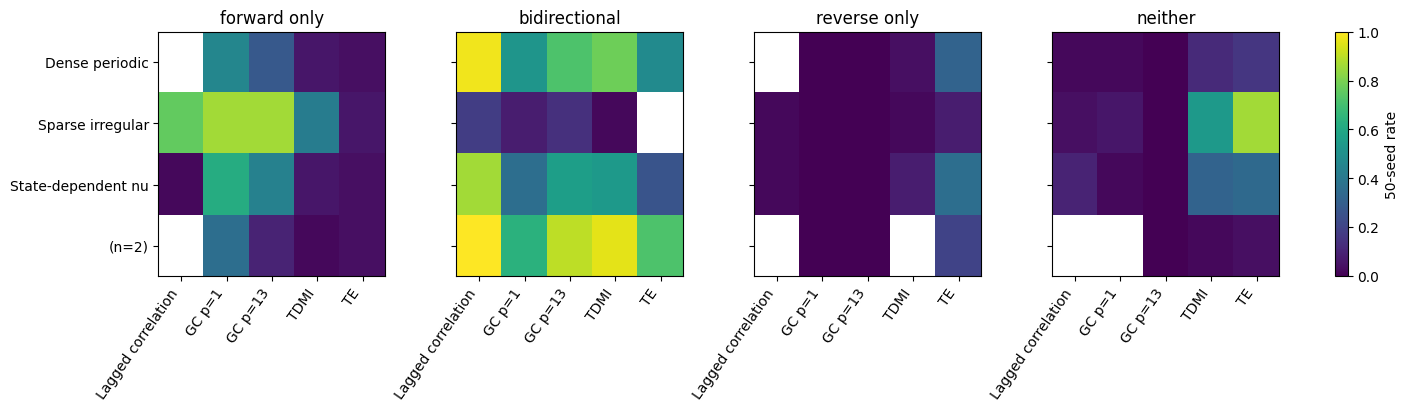

In [3]:
expected_non_null_cases = [
    'Dense periodic (n=1)',
    'Sparse irregular (n=1)',
    'State-dependent nu (n=1)',
    'Locally scale-matched (n=2)',
]
expected_cases = expected_non_null_cases + ['No effect (n=1)']
expected_methods = [
    'Lagged correlation', 'Granger causality p=1', 'Granger causality p=13',
    'TDMI', 'Transfer entropy',
]
expected_transformations = {'levels', 'changes'}
assert set(run_metrics['case_name'].unique()) == set(expected_cases)
assert set(run_metrics['method'].unique()) == set(expected_methods)
assert set(run_metrics['transformation'].unique()) == expected_transformations
assert not run_metrics.duplicated(
    ['case_name', 'seed', 'method', 'transformation']
).any()
expected_groups = pd.MultiIndex.from_product(
    [expected_cases, expected_methods, sorted(expected_transformations)],
    names=['case_name', 'method', 'transformation'],
)
group_sizes = run_metrics.groupby(
    ['case_name', 'method', 'transformation']
).size().reindex(expected_groups)
assert group_sizes.notna().all() and group_sizes.eq(50).all()

method_order = [
    'Lagged correlation',
    'Granger causality p=1',
    'Granger causality p=13',
    'TDMI',
    'Transfer entropy',
]
display_names = {
    'Granger causality p=1': 'GC p=1',
    'Granger causality p=13': 'GC p=13',
    'Transfer entropy': 'TE',
}
non_null_cases = expected_non_null_cases
held_out_seeds = set(config11['calibration_seed_split']['held_out'])
primary = run_metrics.loc[run_metrics['transformation'].eq('changes')].copy()
signal = primary.loc[primary['case_name'].isin(non_null_cases)]
null_held_out = primary.loc[
    primary['case_name'].eq('No effect (n=1)')
    & primary['seed'].isin(held_out_seeds)
]

dependence_rows = []
for method in method_order:
    signal_method = signal.loc[signal['method'].eq(method)]
    null_method = null_held_out.loc[null_held_out['method'].eq(method)]
    directional = signal_method['directional_classification']
    exact_recovery = signal_method['exact_plus_1_recovery'].mean()
    conditional_exact = signal_method.loc[
        signal_method['forward_detected'], 'exact_plus_1_recovery'
    ].mean()
    if method == 'Granger causality p=13':
        exact_recovery = np.nan
        conditional_exact = np.nan
        exact_label = 'Not applicable - joint direct-window test'
    elif method == 'Granger causality p=1':
        exact_label = 'Prespecified (+1) GC evidence'
    else:
        exact_label = 'Peak-based exact (+1) recovery'
    dependence_rows.append({
        'method': display_names.get(method, method),
        'forward dependence detection': signal_method['forward_detected'].mean(),
        'reverse detection': signal_method['reverse_detected'].mean(),
        'forward-only rate': directional.eq('forward only').mean(),
        'bidirectional rate': directional.eq('bidirectional').mean(),
        'exact (+1) recovery': exact_recovery,
        'exact (+1) conditional on forward detection': conditional_exact,
        'exact-lag interpretation': exact_label,
        'direct-window recovery': signal_method['direct_window_recovery'].mean(),
        'held-out forward false-positive rate': null_method['forward_detected'].mean(),
        'held-out reverse false-positive rate': null_method['reverse_detected'].mean(),
        'source notebook': '11',
        'source file': 'notebook11_results/run_metrics.csv',
        'evidence type': '50-seed repeated; changes',
    })
dependence_summary = pd.DataFrame(dependence_rows)
display(dependence_summary)

classification_order = ['forward only', 'bidirectional', 'reverse only', 'neither']
directional_rates = (
    signal.groupby(['case_name', 'method', 'directional_classification'])
    .size()
    .div(50)
    .rename('rate')
    .reset_index()
)
fig, axes = plt.subplots(1, 4, figsize=(14, 4), sharey=True, constrained_layout=True)
for axis, category in zip(axes, classification_order):
    matrix = (
        directional_rates.loc[directional_rates['directional_classification'].eq(category)]
        .pivot(index='case_name', columns='method', values='rate')
        .reindex(index=non_null_cases, columns=method_order, fill_value=0.0)
    )
    image = axis.imshow(matrix.to_numpy(), vmin=0, vmax=1, aspect='auto', cmap='viridis')
    axis.set_title(category)
    axis.set_xticks(range(len(method_order)), [display_names.get(x, x) for x in method_order], rotation=55, ha='right')
    axis.set_yticks(range(len(non_null_cases)), [x.replace(' (n=1)', '').replace('Locally scale-matched ', '') for x in non_null_cases])
fig.colorbar(image, ax=axes, label='50-seed rate')
plt.show()

## Profile recovery, forecasting, calibration and schedule robustness

The repeated checkpoint summaries are used directly. The table is intentionally restricted to active-event metrics where that is the common saved repeated output; overall and event-free metrics are not imputed. Profile shape, scalar parameters and exact immediate response remain distinct quantities.

,setting,summary statistic,number of seeds,source notebook,source file,mean amplitude estimate,mean decay estimate,mean parametric profile RMSE,mean non-parametric profile RMSE,mean parametric active MAE gain (%),active 95% coverage (rate; mean across seeds),mean parametric active interval score
0,Notebook 08 benchmark (n=1),mean; coverage is a rate averaged across seeds,50,08,notebook08_results/notebook08_numeric_summary.csv,0.010204,34.833277,0.000472,0.001025,22.835513,0.944615,0.004199
1,Notebook 09 locally scale-matched (n=2),mean; coverage is a rate averaged across seeds,50,09,notebook09_results/notebook09_calibration_nume...,0.010054,34.855917,0.000278,0.000613,71.149398,0.942857,0.000585
2,dense_periodic,mean; coverage is a rate averaged across seeds,50,10,notebook10_results/stage4_seed_case_analysis.csv,0.010035,33.484357,0.000341,0.000966,23.993758,0.947033,0.004231
3,sparse_irregular,mean; coverage is a rate averaged across seeds,50,10,notebook10_results/stage4_seed_case_analysis.csv,0.009970,37.981729,0.000577,0.001487,17.908709,0.939231,0.004313
4,sparse_periodic,mean; coverage is a rate averaged across seeds,50,10,notebook10_results/stage4_seed_case_analysis.csv,0.009779,33.341572,0.000548,0.001450,18.608068,0.950000,0.004232


### n=2 synthesis

Notebook 09 uses a locally scale-matched n=2 design, which is the appropriate comparison because the powered state and its numerical scale differ from n=1. Within that matched repeated output, n=2 parametric/non-parametric profile RMSE is 0.000278/0.000613, versus 0.000472/0.001025 for the matched n=1 reference. Its active MAE/RMSE gains are 71.1%/69.0% and active 95% coverage is 0.943, close to the matched n=1 value of 0.945. Raw X-space errors and interval scores are not compared across powers without scale awareness. Notebook 11 nevertheless shows greater directional ambiguity in the locally matched n=2 case, so stronger active-window forecast gains do not imply cleaner directional identification.

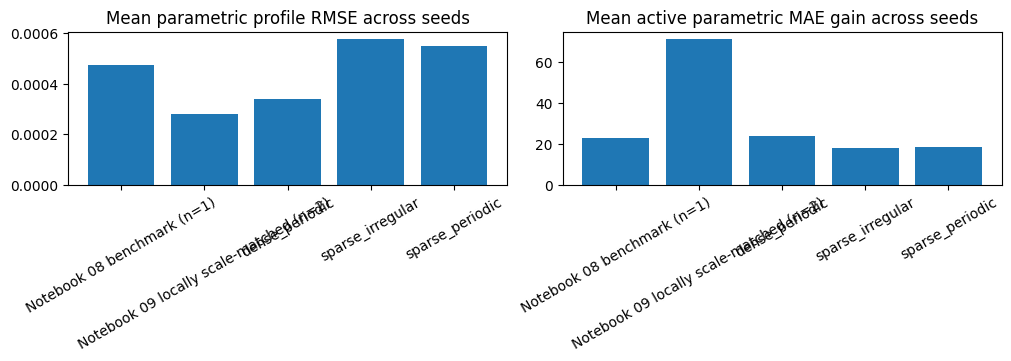

**Notebook 10 headline robustness table:** the compact numerical table above uses means. The checkpoint headline table below reports medians and paired intervals where supplied, so its values are not silently combined with the mean table.

,result_area,dense_periodic,sparse_periodic,sparse_irregular,main_paired_result,interpretation
0,Forward GC change detection,100.00%,98.00%,100.00%,"Sparse periodic - dense: -2.00 pp [-6.02, 2.02...",Predictive detection remains high across sched...
1,Reverse GC change rejection,74.00%,12.00%,10.00%,"Sparse periodic - dense: -62.00 pp [-77.07, -4...",Dense periodic repetition has stronger reverse...
2,Change-TDMI exact +1 recovery,44.00%,34.00%,42.00%,"Sparse periodic - dense: -10.00 pp [-29.26, 9....",Exact-lag recovery is imperfect under every sc...
3,Parametric profile RMSE,0.000341,0.000548,0.000577,"Sparse periodic - dense: 0.000207 [0.000115, 0...",Lower values indicate better profile recovery.
4,Non-parametric profile RMSE,0.000966,0.001450,0.001487,"Sparse periodic - dense: 0.000484 [0.000416, 0...",Lower values indicate better profile recovery.
5,Parametric active MAE gain,25.19 pp,19.00 pp,18.94 pp,"Sparse periodic - dense: -5.39 pp [-7.34, -3.4...",Positive gains favour event-aware forecasting.
6,Non-parametric active MAE gain,22.13 pp,15.72 pp,13.42 pp,"Sparse periodic - dense: -6.55 pp [-8.69, -4.4...",Positive gains favour event-aware forecasting.
7,Parametric active 95% coverage,0.947,0.950,0.939,"Sparse periodic - dense: 0.0030 [-0.0032, 0.00...",Coverage is evaluated jointly with interval sc...
8,Parametric interval score,0.004231,0.004232,0.004313,"Sparse periodic - dense: 0.000001 [-0.000101, ...",Lower interval scores are better conditional o...


In [4]:
metrics08 = [
    'A_hat', 'lambda_hat', 'parametric_profile_RMSE', 'nonparametric_profile_RMSE',
    'parametric_active_MAE_gain_pct', 'parametric_active_95_state_coverage',
    'parametric_active_95_state_interval_score',
]
profile_forecast08 = summary08.loc[
    summary08['metric'].isin(metrics08)
    & summary08['case_name'].eq('benchmark'),
    ['case_name', 'metric', 'mean', 'ci_95_lower', 'ci_95_upper', 'count'],
].copy()
profile_forecast08['source notebook'] = '08'
profile_forecast08['source file'] = 'notebook08_results/notebook08_numeric_summary.csv'

metrics09 = [
    'A_hat', 'lambda_hat', 'parametric_profile_RMSE', 'nonparametric_profile_RMSE',
    'parametric_active_MAE_gain_pct', 'parametric_active_95_state_coverage',
    'parametric_active_95_state_interval_score',
]
profile_forecast09 = summary09.loc[
    summary09['metric'].isin(metrics09)
    & summary09['case_name'].eq('n2_benchmark'),
    ['case_name', 'metric', 'mean', 'ci_95_lower', 'ci_95_upper', 'count'],
].copy()
profile_forecast09['source notebook'] = '09'
profile_forecast09['source file'] = 'notebook09_results/notebook09_calibration_numeric_summary.csv'

metric_labels = {
    'A_hat': 'mean amplitude estimate',
    'lambda_hat': 'mean decay estimate',
    'parametric_profile_RMSE': 'mean parametric profile RMSE',
    'nonparametric_profile_RMSE': 'mean non-parametric profile RMSE',
    'parametric_active_MAE_gain_pct': 'mean parametric active MAE gain (%)',
    'parametric_active_95_state_coverage': 'active 95% coverage (rate; mean across seeds)',
    'parametric_active_95_state_interval_score': 'mean parametric active interval score',
}

def checkpoint_summary_row(long_table, setting, source_notebook, source_file):
    values = long_table.set_index('metric')['mean'].to_dict()
    counts = long_table.set_index('metric')['count'].to_dict()
    row = {
        'setting': setting,
        'summary statistic': 'mean; coverage is a rate averaged across seeds',
        'number of seeds': int(next(iter(counts.values()))) if counts else np.nan,
        'source notebook': source_notebook,
        'source file': source_file,
    }
    for metric, label in metric_labels.items():
        row[label] = values.get(metric, np.nan)
    return row

schedule_columns = [
    'case_name', 'A_hat', 'lambda_hat',
    'active_sigma_parametric_MAE_gain_pct',
    'active_95_state_parametric_coverage',
    'active_95_state_parametric_interval_score',
    'parametric_profile_RMSE', 'nonparametric_profile_RMSE',
]
schedule_summary = (
    schedule_runs[schedule_columns]
    .groupby('case_name', as_index=False)
    .mean(numeric_only=True)
)
schedule_summary['number of seeds'] = schedule_runs.groupby('case_name').size().to_numpy()
schedule_summary['summary statistic'] = 'mean; coverage is a rate averaged across seeds'
schedule_summary['source notebook'] = '10'
schedule_summary['source file'] = 'notebook10_results/stage4_seed_case_analysis.csv'
schedule_summary = schedule_summary.rename(columns={
    'case_name': 'setting',
    'A_hat': 'mean amplitude estimate',
    'lambda_hat': 'mean decay estimate',
    'parametric_profile_RMSE': 'mean parametric profile RMSE',
    'nonparametric_profile_RMSE': 'mean non-parametric profile RMSE',
    'active_sigma_parametric_MAE_gain_pct': 'mean parametric active MAE gain (%)',
    'active_95_state_parametric_coverage': 'active 95% coverage (rate; mean across seeds)',
    'active_95_state_parametric_interval_score': 'mean parametric active interval score',
})

repeated_evidence = pd.DataFrame([
    checkpoint_summary_row(
        profile_forecast08,
        'Notebook 08 benchmark (n=1)',
        '08',
        'notebook08_results/notebook08_numeric_summary.csv',
    ),
    checkpoint_summary_row(
        profile_forecast09,
        'Notebook 09 locally scale-matched (n=2)',
        '09',
        'notebook09_results/notebook09_calibration_numeric_summary.csv',
    ),
])
repeated_evidence = pd.concat([repeated_evidence, schedule_summary], ignore_index=True)
display(repeated_evidence)

n2_metrics = summary09.loc[
    summary09['case_name'].isin(['n1_reference', 'n2_benchmark'])
    & summary09['metric'].isin([
        'parametric_profile_RMSE', 'nonparametric_profile_RMSE',
        'parametric_active_MAE_gain_pct', 'parametric_active_RMSE_gain_pct',
        'parametric_active_95_state_coverage',
        'parametric_active_95_state_interval_score',
    ]),
].pivot(index='metric', columns='case_name', values='mean')
n2_note = (
    '### n=2 synthesis\n\n'
    'Notebook 09 uses a locally scale-matched n=2 design, which is the appropriate comparison because the powered state and its numerical scale differ from n=1. '
    f"Within that matched repeated output, n=2 parametric/non-parametric profile RMSE is {n2_metrics.loc['parametric_profile_RMSE', 'n2_benchmark']:.6f}/"
    f"{n2_metrics.loc['nonparametric_profile_RMSE', 'n2_benchmark']:.6f}, versus {n2_metrics.loc['parametric_profile_RMSE', 'n1_reference']:.6f}/"
    f"{n2_metrics.loc['nonparametric_profile_RMSE', 'n1_reference']:.6f} for the matched n=1 reference. "
    f"Its active MAE/RMSE gains are {n2_metrics.loc['parametric_active_MAE_gain_pct', 'n2_benchmark']:.1f}%/"
    f"{n2_metrics.loc['parametric_active_RMSE_gain_pct', 'n2_benchmark']:.1f}% and active 95% coverage is "
    f"{n2_metrics.loc['parametric_active_95_state_coverage', 'n2_benchmark']:.3f}, close to the matched n=1 value of "
    f"{n2_metrics.loc['parametric_active_95_state_coverage', 'n1_reference']:.3f}. "
    'Raw X-space errors and interval scores are not compared across powers without scale awareness. Notebook 11 nevertheless shows greater directional ambiguity in the locally matched n=2 case, so stronger active-window forecast gains do not imply cleaner directional identification.'
)
display(Markdown(n2_note))

fig, axes = plt.subplots(1, 2, figsize=(10, 3.5), constrained_layout=True)
axes[0].bar(repeated_evidence['setting'], repeated_evidence['mean parametric profile RMSE'])
axes[0].set_title('Mean parametric profile RMSE across seeds')
axes[0].tick_params(axis='x', rotation=30)
axes[1].bar(repeated_evidence['setting'], repeated_evidence['mean parametric active MAE gain (%)'])
axes[1].set_title('Mean active parametric MAE gain across seeds')
axes[1].tick_params(axis='x', rotation=30)
plt.show()

display(Markdown('**Notebook 10 headline robustness table:** the compact numerical table above uses means. The checkpoint headline table below reports medians and paired intervals where supplied, so its values are not silently combined with the mean table.'))
display(schedule_headlines)

## Focused nonlinear and log-state exploration

Notebook 07 explores a state-dependent \(\nu\) specification as a focused one-seed test of whether the frozen workflow remains usable under nonlinear background dynamics. Because it is not a repeated-seed experiment, it is treated as exploratory evidence rather than general nonlinear robustness.

## Log-state decomposition and interpretation boundary

Notebook 12 is a focused one-seed matched-feature exploration. Since \(X_{t+1}=\omega_{t+1}^{n/2}F_t\), \(\log X_{t+1}=\tfrac n2\log\omega_{t+1}+\log F_t\). This makes the event term additive but neither removes the need to estimate \(\log F_t\) nor implies statistical independence. Its stored conclusion is preserved as exploratory evidence: decay recovery improved slightly, while amplitude and profile recovery, active forecasts, residual dependence and interval calibration deteriorated under the retained raw linear predictor basis. No nonlinear log baseline is added here.

## Overall method comparison, robust findings and transition

The comparison matrix is descriptive rather than a score or ranking. “Exact-lag capability” distinguishes a prespecified p=1 GC test from peak selection, and records the joint nature of GC p=13.

For methods that can identify a unique lag, the strongest and weakest observed settings are selected first by exact-(+1) recovery, then by forward-only classification rate, and finally by forward detection rate. For GC (p=13), which is a joint direct-window test, direct-window recovery replaces exact-(+1) recovery. These labels summarise the studied cases and are not universal rankings.

In [5]:
case_method_changes = (
    signal.groupby(['method', 'case_name'], as_index=False)
    .agg(
        forward_detection=('forward_detected', 'mean'),
        forward_only=('directional_classification', lambda x: x.eq('forward only').mean()),
        exact_recovery=('exact_plus_1_recovery', 'mean'),
        direct_window_recovery=('direct_window_recovery', 'mean'),
    )
)

def observed_method_setting(method, strongest):
    candidates = case_method_changes.loc[case_method_changes['method'].eq(method)].copy()
    if method == 'Granger causality p=13':
        sort_columns = ['direct_window_recovery', 'forward_only', 'forward_detection']
        lag_label = 'direct-window'
    else:
        sort_columns = ['exact_recovery', 'forward_only', 'forward_detection']
        lag_label = 'exact +1'
    selected = candidates.sort_values(sort_columns, ascending=not strongest).iloc[0]
    lag_value = selected['direct_window_recovery'] if method == 'Granger causality p=13' else selected['exact_recovery']
    return (
        f"{selected['case_name']} changes (forward {selected['forward_detection']:.0%}; "
        f"forward-only {selected['forward_only']:.0%}; {lag_label} {lag_value:.0%})"
    )

n1_repeated_evidence = repeated_evidence.loc[
    ~repeated_evidence['setting'].str.contains('n=2', na=False)
].copy()

def observed_n1_setting(metric, strongest):
    candidates = n1_repeated_evidence.dropna(subset=[metric])
    selected = candidates.sort_values(metric, ascending=not strongest).iloc[0]
    return f"{selected['setting']} (mean {selected[metric]:.6g})"

lag_methods = [
    ('Lagged correlation', 'Lagged correlation'),
    ('GC p=1', 'Granger causality p=1'),
    ('GC p=13', 'Granger causality p=13'),
    ('TDMI', 'TDMI'),
    ('TE', 'Transfer entropy'),
]
observed_settings = {
    display_name: (
        observed_method_setting(raw_name, strongest=True),
        observed_method_setting(raw_name, strongest=False),
    )
    for display_name, raw_name in lag_methods
}
parametric_profile_strong = observed_n1_setting('mean parametric profile RMSE', strongest=False)
parametric_profile_weak = observed_n1_setting('mean parametric profile RMSE', strongest=True)
nonparametric_profile_strong = observed_n1_setting('mean non-parametric profile RMSE', strongest=False)
nonparametric_profile_weak = observed_n1_setting('mean non-parametric profile RMSE', strongest=True)
forecast_strong = observed_n1_setting('mean parametric active MAE gain (%)', strongest=True)
forecast_weak = observed_n1_setting('mean parametric active MAE gain (%)', strongest=False)

method_comparison = pd.DataFrame([
    ('Lagged correlation', 'descriptive lagged association', observed_settings['Lagged correlation'][0], observed_settings['Lagged correlation'][1], 'peak-based (+1)', 'limited to transformation used', 'high under sparse events', 'empirical held-out thresholds', 'low', 'periodic aliases and no formal structural test', 'Level 2'),
    ('GC p=1', 'prespecified exact-(+1) predictive evidence', observed_settings['GC p=1'][0], observed_settings['GC p=1'][1], 'prespecified (+1)', 'linear autoregression', 'moderate', 'formal F-test and held-out null evaluation', 'low', 'predictive rather than structural causation', 'Level 2'),
    ('GC p=13', 'joint direct-window predictive evidence', observed_settings['GC p=13'][0], observed_settings['GC p=13'][1], 'not applicable - joint test', 'linear autoregression', 'moderate', 'formal F-test and held-out null evaluation', 'moderate', 'does not identify a unique lag', 'Level 2'),
    ('TDMI', 'nonlinear lagged dependence description', observed_settings['TDMI'][0], observed_settings['TDMI'][1], 'peak-based (+1)', 'nonlinear dependence estimate', 'high', 'empirical held-out thresholds', 'moderate', 'finite-sample and periodic peaks', 'Level 2'),
    ('TE', 'directed information-flow diagnostic', observed_settings['TE'][0], observed_settings['TE'][1], 'lag-grid peak, not structural proof', 'binned nonlinear estimator', 'high', 'surrogate validation and empirical held-out thresholds', 'high', 'binning and sample-size sensitivity', 'Level 2'),
    ('Parametric event-profile estimation', 'recover event shape and scalar parameters', parametric_profile_strong, parametric_profile_weak, 'immediate response evaluated separately', 'specified exponential profile', 'moderate to high', 'Not applicable as a significance test; evaluated post-fit against the Known-DGP reference', 'low', 'shape assumption', 'Level 2'),
    ('Non-parametric event-profile estimation', 'recover age-specific response', nonparametric_profile_strong, nonparametric_profile_weak, 'immediate response evaluated separately', 'age-cell means', 'high', 'Not applicable as a significance test; evaluated post-fit against the Known-DGP reference', 'low', 'event-age sample scarcity', 'Level 2'),
    ('Event-aware forecasting', 'active-window forecast improvement', forecast_strong, forecast_weak, 'not a lag estimator', 'inherits baseline specification', 'moderate', 'Chronological out-of-sample evaluation with separate point and interval metrics', 'low to moderate', 'active gains need not improve overall results or calibration', 'Level 2'),
    ('Log-state decomposition', 'algebraic additive event term', 'one-seed matched-feature prototype; repeated strongest setting not assessed', 'one-seed matched-feature prototype; repeated weakest setting not assessed', 'not a lag estimator', 'no nonlinear log baseline tested', 'not assessed repeatedly', 'One-seed matched comparison against the original-state implementation', 'low to moderate', 'one-seed and background-baseline misspecification', 'Level 3'),
], columns=[
    'method', 'primary purpose', 'strongest observed setting', 'weakest observed setting',
    'exact-lag capability', 'nonlinear capability', 'sparse-event sensitivity',
    'validation or null-control approach', 'computational cost', 'main limitation', 'evidence strength',
])
method_comparison.to_csv(OUTPUT_DIR / 'method_comparison.csv', index=False)
display(method_comparison)

unique_lag_methods = [
    'Lagged correlation', 'Granger causality p=1', 'TDMI', 'Transfer entropy',
]
lag_evidence_rows = []
for transformation in ('levels', 'changes'):
    subset = run_metrics.loc[
        run_metrics['case_name'].isin(non_null_cases)
        & run_metrics['method'].isin(unique_lag_methods)
        & run_metrics['transformation'].eq(transformation)
    ]
    lag_evidence_rows.append({
        'transformation': transformation,
        'average forward detection': subset['forward_detected'].mean(),
        'average exact (+1) recovery': subset['exact_plus_1_recovery'].mean(),
        'exact (+1) conditional on forward detection': subset.loc[
            subset['forward_detected'], 'exact_plus_1_recovery'
        ].mean(),
    })
lag_evidence = pd.DataFrame(lag_evidence_rows).set_index('transformation')
display(lag_evidence.reset_index())
level_lag_evidence = lag_evidence.loc['levels']
change_lag_evidence = lag_evidence.loc['changes']
changes_finding = (
    f"Across the four non-null cases and methods with unique-lag summaries, changes average "
    f"{change_lag_evidence['average forward detection']:.1%} forward detection and "
    f"{change_lag_evidence['average exact (+1) recovery']:.1%} exact (+1) recovery, versus "
    f"{level_lag_evidence['average forward detection']:.1%} and "
    f"{level_lag_evidence['average exact (+1) recovery']:.1%} for levels. "
    f"Conditional exact recovery is {change_lag_evidence['exact (+1) conditional on forward detection']:.1%} for changes "
    f"and {level_lag_evidence['exact (+1) conditional on forward detection']:.1%} for levels, so the conditional advantage is not uniform."
)

core_findings = pd.DataFrame([
    ('robust', 'Dependence detection is easier than exact lag and direction recovery; periodic schedules can create aliases and bidirectional predictive evidence.', '11', 'notebook11_results/run_metrics.csv', '50-seed repeated comparison'),
    ('robust', changes_finding, '11', 'notebook11_results/run_metrics.csv', '50-seed repeated level/change comparison'),
    ('robust', 'Event-aware forecasting is most useful during active windows; point accuracy and interval calibration require separate assessment.', '08, 09, 10', 'repeated numeric and schedule summaries', '50-seed repeated evidence'),
    ('robust', 'Within the three studied schedules, event scarcity is more damaging than irregular timing alone; this is not a universal schedule theorem.', '10', 'notebook10_results/stage5_final_evidence.csv', '50 paired seeds'),
    ('robust', 'Locally scale-matched n=2 requires scale-aware interpretation and can increase directional ambiguity.', '09, 11', 'notebook09_results; notebook11_results/run_metrics.csv', 'repeated evidence'),
    ('conditional', 'The exact ordering of GC, TDMI and TE depends on case, representation and calibration; no universal winner is established.', '11', 'notebook11_results/run_metrics.csv', 'case-dependent repeated comparison'),
    ('conditional', 'Notebook 07 explores a state-dependent nu specification as a focused one-seed test of whether the frozen workflow remains usable under nonlinear background dynamics; it is exploratory rather than general nonlinear robustness.', '07', 'experiment-design provenance; no numerical result extracted', 'one-seed exploratory'),
    ('conditional', 'The matched-feature log decomposition clarifies algebra but is mostly inferior in its one-seed implementation; this is not a universal log-model result.', '12', 'stored executed notebook output', 'one-seed exploratory'),
    ('conditional', 'Parametric versus non-parametric profile advantages depend on schedule, signal and event-age sample size.', '03, 08, 09, 10', 'profile checkpoint summaries', 'mixed repeated and exploratory evidence'),
], columns=['finding class', 'finding', 'source notebook', 'source file', 'evidence type'])
core_findings.to_csv(OUTPUT_DIR / 'core_findings.csv', index=False)
robust_findings = core_findings.loc[core_findings['finding class'].eq('robust')]
conditional_findings = core_findings.loc[core_findings['finding class'].eq('conditional')]
display(Markdown('### Robust findings'))
display(robust_findings)
display(Markdown('### Conditional or exploratory findings'))
display(conditional_findings)

provenance = pd.DataFrame([
    ('experiment registry', '00–12', 'notebook filenames and executed workspace', 'registry assembly', 'varies', 'manual descriptive assembly'),
    ('dependence and directional summary', '11', 'notebook11_results/run_metrics.csv; experiment_config.json', 'automated checkpoint aggregation', '50', 'changes; held-out no-effect seeds for FPR'),
    ('TE validation status', '11', 'notebook11_results/te_validation.csv; manifest.json', 'automated checkpoint read', '30 validation seeds', 'all stored validation criteria passed'),
    ('n=1 parameter robustness', '08', 'notebook08_results/notebook08_numeric_summary.csv', 'automated checkpoint read', '50 per case', 'benchmark rows only in compact display'),
    ('n=2 robustness', '09', 'notebook09_results/notebook09_calibration_numeric_summary.csv', 'automated checkpoint read', '50', 'locally scale-matched case'),
    ('nonlinear functional design', '07', 'stored notebook design; no checkpoint extraction', 'experiment-design provenance; one-seed exploratory evidence', '1', 'no numerical result extracted'),
    ('schedule robustness', '10', 'notebook10_results/stage4_seed_case_analysis.csv; stage5_headline_results.csv', 'automated checkpoint aggregation', '50 paired', 'dense, sparse periodic, sparse irregular'),
    ('log decomposition', '12', 'stored executed notebook output', 'manual stored-output inspection with nbformat', '1', 'qualitative result only'),
], columns=['synthesis output', 'source notebook', 'source file or checkpoint', 'extraction method', 'number of seeds', 'note'])
provenance.to_csv(OUTPUT_DIR / 'provenance.csv', index=False)
display(provenance)

missing_machine_readable_sources = [
    'Notebooks 00–07: no exported result folder available for automated synthesis',
    'Notebook 12: no result folder; stored executed output read qualitatively',
]
manifest = {
    'notebook_name': '13_final_synthetic_synthesis.ipynb',
    'creation_timestamp_utc': datetime.now(timezone.utc).isoformat(),
    'source_notebooks': [f'{i:02d}' for i in range(13)],
    'source_checkpoint_folders': [
        'notebook08_results', 'notebook09_results', 'notebook10_results', 'notebook11_results',
    ],
    'missing_sources': missing_machine_readable_sources,
    'number_of_synthesis_rows': {
        'experiment_registry': int(len(experiment_registry)),
        'core_findings': int(len(core_findings)),
        'method_comparison': int(len(method_comparison)),
        'provenance': int(len(provenance)),
    },
    'source_experiments_rerun': False,
}
(OUTPUT_DIR / 'manifest.json').write_text(json.dumps(manifest, indent=2), encoding='utf-8')
assert not source_experiments_rerun
assert dependence_summary.loc[dependence_summary['method'].eq('GC p=13'), 'exact (+1) recovery'].isna().all()

,method,primary purpose,strongest observed setting,weakest observed setting,exact-lag capability,nonlinear capability,sparse-event sensitivity,validation or null-control approach,computational cost,main limitation,evidence strength
0,Lagged correlation,descriptive lagged association,Locally scale-matched (n=2) changes (forward 1...,State-dependent nu (n=1) changes (forward 88%;...,peak-based (+1),limited to transformation used,high under sparse events,empirical held-out thresholds,low,periodic aliases and no formal structural test,Level 2
1,GC p=1,prespecified exact-(+1) predictive evidence,Locally scale-matched (n=2) changes (forward 1...,Sparse irregular (n=1) changes (forward 94%; f...,prespecified (+1),linear autoregression,moderate,formal F-test and held-out null evaluation,low,predictive rather than structural causation,Level 2
2,GC p=13,joint direct-window predictive evidence,Sparse irregular (n=1) changes (forward 100%; ...,Locally scale-matched (n=2) changes (forward 1...,not applicable - joint test,linear autoregression,moderate,formal F-test and held-out null evaluation,moderate,does not identify a unique lag,Level 2
3,TDMI,nonlinear lagged dependence description,Locally scale-matched (n=2) changes (forward 9...,State-dependent nu (n=1) changes (forward 60%;...,peak-based (+1),nonlinear dependence estimate,high,empirical held-out thresholds,moderate,finite-sample and periodic peaks,Level 2
4,TE,directed information-flow diagnostic,Locally scale-matched (n=2) changes (forward 7...,State-dependent nu (n=1) changes (forward 30%;...,"lag-grid peak, not structural proof",binned nonlinear estimator,high,surrogate validation and empirical held-out th...,high,binning and sample-size sensitivity,Level 2
5,Parametric event-profile estimation,recover event shape and scalar parameters,dense_periodic (mean 0.000341166),sparse_irregular (mean 0.000576878),immediate response evaluated separately,specified exponential profile,moderate to high,Not applicable as a significance test; evaluat...,low,shape assumption,Level 2
6,Non-parametric event-profile estimation,recover age-specific response,dense_periodic (mean 0.000965962),sparse_irregular (mean 0.00148749),immediate response evaluated separately,age-cell means,high,Not applicable as a significance test; evaluat...,low,event-age sample scarcity,Level 2
7,Event-aware forecasting,active-window forecast improvement,dense_periodic (mean 23.9938),sparse_irregular (mean 17.9087),not a lag estimator,inherits baseline specification,moderate,Chronological out-of-sample evaluation with se...,low to moderate,active gains need not improve overall results ...,Level 2
8,Log-state decomposition,algebraic additive event term,one-seed matched-feature prototype; repeated s...,one-seed matched-feature prototype; repeated w...,not a lag estimator,no nonlinear log baseline tested,not assessed repeatedly,One-seed matched comparison against the origin...,low to moderate,one-seed and background-baseline misspecification,Level 3


,transformation,average forward detection,average exact (+1) recovery,exact (+1) conditional on forward detection
0,levels,0.3600,0.51000,0.843750
1,changes,0.7625,0.61625,0.706557


### Robust findings

,finding class,finding,source notebook,source file,evidence type
0,robust,Dependence detection is easier than exact lag ...,11,notebook11_results/run_metrics.csv,50-seed repeated comparison
1,robust,Across the four non-null cases and methods wit...,11,notebook11_results/run_metrics.csv,50-seed repeated level/change comparison
2,robust,Event-aware forecasting is most useful during ...,"08, 09, 10",repeated numeric and schedule summaries,50-seed repeated evidence
3,robust,"Within the three studied schedules, event scar...",10,notebook10_results/stage5_final_evidence.csv,50 paired seeds
4,robust,Locally scale-matched n=2 requires scale-aware...,"09, 11",notebook09_results; notebook11_results/run_met...,repeated evidence


### Conditional or exploratory findings

,finding class,finding,source notebook,source file,evidence type
5,conditional,"The exact ordering of GC, TDMI and TE depends ...",11,notebook11_results/run_metrics.csv,case-dependent repeated comparison
6,conditional,Notebook 07 explores a state-dependent nu spec...,07,experiment-design provenance; no numerical res...,one-seed exploratory
7,conditional,The matched-feature log decomposition clarifie...,12,stored executed notebook output,one-seed exploratory
8,conditional,Parametric versus non-parametric profile advan...,"03, 08, 09, 10",profile checkpoint summaries,mixed repeated and exploratory evidence


,synthesis output,source notebook,source file or checkpoint,extraction method,number of seeds,note
0,experiment registry,00–12,notebook filenames and executed workspace,registry assembly,varies,manual descriptive assembly
1,dependence and directional summary,11,notebook11_results/run_metrics.csv; experiment...,automated checkpoint aggregation,50,changes; held-out no-effect seeds for FPR
2,TE validation status,11,notebook11_results/te_validation.csv; manifest...,automated checkpoint read,30 validation seeds,all stored validation criteria passed
3,n=1 parameter robustness,08,notebook08_results/notebook08_numeric_summary.csv,automated checkpoint read,50 per case,benchmark rows only in compact display
4,n=2 robustness,09,notebook09_results/notebook09_calibration_nume...,automated checkpoint read,50,locally scale-matched case
5,nonlinear functional design,07,stored notebook design; no checkpoint extraction,experiment-design provenance; one-seed explora...,1,no numerical result extracted
6,schedule robustness,10,notebook10_results/stage4_seed_case_analysis.c...,automated checkpoint aggregation,50 paired,"dense, sparse periodic, sparse irregular"
7,log decomposition,12,stored executed notebook output,manual stored-output inspection with nbformat,1,qualitative result only


## Limitations and transition towards real data

The synthetic environment has a known simple calendar, one event channel, fixed horizon, finite samples, estimator and discretisation choices, periodicity/scarcity stresses, limited nonlinear-function exploration, and no option-surface or multichannel structure. These limits motivate—not invalidate—the next stage. Real-data work should begin with scheduled central-bank events, timestamped non-overlapping windows, daily ATM implied volatility, matched non-event baselines, and stable descriptive/causal diagnostics. RR, BF, multiple maturities and finer data can follow. Event-aware forecasting should be added only after those diagnostics are stable.

## Final synthesis

The conclusion below is generated from the synthesis tables. It retains the distinction between robust repeated evidence and focused exploratory diagnostics.

In [6]:
forward_detection_range = (
    dependence_summary['forward dependence detection'].min(),
    dependence_summary['forward dependence detection'].max(),
)
benchmark08 = repeated_evidence.loc[
    repeated_evidence['setting'].eq('Notebook 08 benchmark (n=1)')
].iloc[0]
benchmark09 = repeated_evidence.loc[
    repeated_evidence['setting'].eq('Notebook 09 locally scale-matched (n=2)')
].iloc[0]
schedule_gain_range = (
    schedule_summary['mean parametric active MAE gain (%)'].min(),
    schedule_summary['mean parametric active MAE gain (%)'].max(),
)
robust_count = int(core_findings['finding class'].eq('robust').sum())
conditional_count = int(core_findings['finding class'].eq('conditional').sum())
conclusion = '## Final synthetic conclusion\n\n'
conclusion += (
    'The synthetic exploration validated frozen timing, leakage-safe transition and forecast workflows, '
    'Known-DGP post-fit profile evaluation, null controls, calibration metrics, and dependence diagnostics under periodicity and sparsity. '
)
conclusion += (
    f"Notebook 11's four-case repeated comparison gives change-series forward detection of "
    f"{change_lag_evidence['average forward detection']:.1%} versus {level_lag_evidence['average forward detection']:.1%} for levels, "
    f"and exact (+1) recovery of {change_lag_evidence['average exact (+1) recovery']:.1%} versus "
    f"{level_lag_evidence['average exact (+1) recovery']:.1%}. Conditional exact recovery is "
    f"{change_lag_evidence['exact (+1) conditional on forward detection']:.1%} for changes versus "
    f"{level_lag_evidence['exact (+1) conditional on forward detection']:.1%} for levels. "
    'This reinforces that dependence detection is not the same as exact structural-lag recovery. GC p=1 remains prespecified exact-(+1) Granger-predictive evidence; GC p=13 remains a joint direct-window test without a unique lag. '
)
conclusion += (
    f"Notebook 08's repeated n=1 benchmark has mean parametric/non-parametric profile RMSE of "
    f"{benchmark08['mean parametric profile RMSE']:.6f}/{benchmark08['mean non-parametric profile RMSE']:.6f} and mean active parametric MAE gain of "
    f"{benchmark08['mean parametric active MAE gain (%)']:.1f}%. Notebook 09's locally scale-matched n=2 output reports "
    f"{benchmark09['mean parametric active MAE gain (%)']:.1f}% active MAE gain and {benchmark09['active 95% coverage (rate; mean across seeds)']:.3f} active coverage; its profile and forecast results must be read on their own scale, while Notebook 11 shows greater directional ambiguity for n=2. "
)
conclusion += (
    f"Across Notebook 10's studied schedules, mean active parametric MAE gains span {schedule_gain_range[0]:.1f}% to {schedule_gain_range[1]:.1f}%; "
    'event scarcity is more damaging than irregular timing alone within those designs. Periodic schedules can generate aliases and reverse predictive evidence, not physical reverse causation, and calibration remains separate from point accuracy. '
)
conclusion += (
    'Notebook 07 explores a state-dependent nu specification as a focused one-seed test of the frozen workflow under nonlinear background dynamics; it remains exploratory rather than general nonlinear robustness. '
    'Notebook 12 shows that the one-seed matched-feature log decomposition makes the event term algebraically additive but does not improve that implementation. '
)
conclusion += (
    f"The synthesis records {robust_count} robust and {conditional_count} conditional findings; no single method universally dominates. "
    'The validated timing, null-testing, profile, forecasting and calibration workflow is ready to transfer to carefully timestamped real FX-event and options data, without claiming interventionist causality.'
)
display(Markdown(conclusion))
print('Source experiments rerun:', source_experiments_rerun)
print('Synthesis outputs:', ', '.join(sorted(path.name for path in OUTPUT_DIR.iterdir())))

## Final synthetic conclusion

The synthetic exploration validated frozen timing, leakage-safe transition and forecast workflows, Known-DGP post-fit profile evaluation, null controls, calibration metrics, and dependence diagnostics under periodicity and sparsity. Notebook 11's four-case repeated comparison gives change-series forward detection of 76.2% versus 36.0% for levels, and exact (+1) recovery of 61.6% versus 51.0%. Conditional exact recovery is 70.7% for changes versus 84.4% for levels. This reinforces that dependence detection is not the same as exact structural-lag recovery. GC p=1 remains prespecified exact-(+1) Granger-predictive evidence; GC p=13 remains a joint direct-window test without a unique lag. Notebook 08's repeated n=1 benchmark has mean parametric/non-parametric profile RMSE of 0.000472/0.001025 and mean active parametric MAE gain of 22.8%. Notebook 09's locally scale-matched n=2 output reports 71.1% active MAE gain and 0.943 active coverage; its profile and forecast results must be read on their own scale, while Notebook 11 shows greater directional ambiguity for n=2. Across Notebook 10's studied schedules, mean active parametric MAE gains span 17.9% to 24.0%; event scarcity is more damaging than irregular timing alone within those designs. Periodic schedules can generate aliases and reverse predictive evidence, not physical reverse causation, and calibration remains separate from point accuracy. Notebook 07 explores a state-dependent nu specification as a focused one-seed test of the frozen workflow under nonlinear background dynamics; it remains exploratory rather than general nonlinear robustness. Notebook 12 shows that the one-seed matched-feature log decomposition makes the event term algebraically additive but does not improve that implementation. The synthesis records 5 robust and 4 conditional findings; no single method universally dominates. The validated timing, null-testing, profile, forecasting and calibration workflow is ready to transfer to carefully timestamped real FX-event and options data, without claiming interventionist causality.

Source experiments rerun: False
Synthesis outputs: core_findings.csv, experiment_registry.csv, manifest.json, method_comparison.csv, provenance.csv
